The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

In [1]:
!uv add scikit-learn pandas numpy matplotlib seaborn

Resolved 52 packages in 3ms
Audited 20 packages in 0.02ms


In [81]:

import matplotlib.pyplot as plt
from sklearn import svm
import seaborn as sns
import pandas as pd
import numpy as np

import itertools

sns.set_theme(style='whitegrid', palette='pastel')

In [75]:
df = pd.read_csv("dataset_credit_card_fraud.csv")

In [76]:
df = df.rename(columns={
    'Time': 'time',
    'V1': 'v1',
    'V2': 'v2',
    'V3': 'v3',
    'V4': 'v4',
    'V5': 'v5',
    'V6': 'v6',
    'V7': 'v7',
    'V8': 'v8',
    'V9': 'v9',
    'V10': 'v10',
    'V11': 'v11',
    'V12': 'v12',
    'V13': 'v13',
    'V14': 'v14',
    'V15': 'v15',
    'V16': 'v16',
    'V17': 'v17',
    'V18': 'v18',
    'V19': 'v19',
    'V20': 'v20',
    'V21': 'v21',
    'V22': 'v22',
    'V23': 'v23',
    'V24': 'v24',
    'V25': 'v25',
    'V26': 'v26',
    'V27': 'v27',
    'V28': 'v28',
    'Amount': 'amount',
    'Class': 'class'
})
df.describe()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


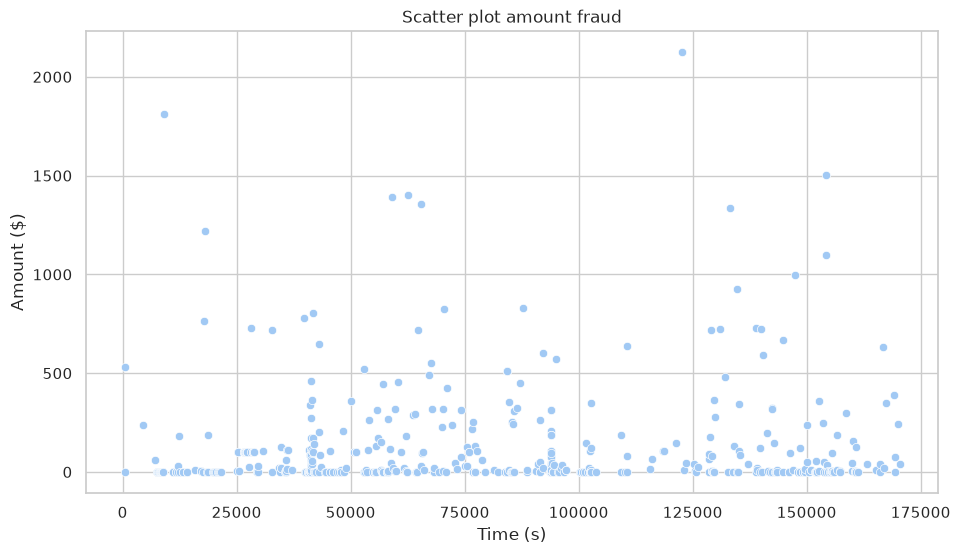

In [77]:
fraud_df = df[df['class'] == 1]

ax = sns.scatterplot(
    data=fraud_df, 
    x='time', 
    y='amount'
)
ax.set_title("Scatter plot amount fraud")
ax.set_ylabel("Amount ($)")
ax.set_xlabel("Time (s)")
ax.figure.set_size_inches(11, 6)

In [37]:
fraud_count = len(df[df['class'] == 1])
no_fraud_count = len(df[df['class'] == 0])
print(f"Fraud count:\t{fraud_count}\nNo fraud count:\t{no_fraud_count}")

Fraud count:	492
No fraud count:	284315


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline         
from sklearn.preprocessing import StandardScaler    
from sklearn.svm import SVC                        
from sklearn.neural_network import MLPClassifier     
from sklearn.model_selection import GridSearchCV 
from sklearn.calibration import CalibratedClassifierCV

In [163]:
undersampled_df_len = 30000

df_train_all = df[0:undersampled_df_len]

df_train_1 = df_train_all[df_train_all['class'] == 1]
df_train_0 = df_train_all[df_train_all['class'] == 0]

print('In this dataset, we have ' + str(len(df_train_1)) +" frauds so we need to take a similar number of non-fraud")

df_sample = df_train_0.sample(300)
df_train = pd.concat([df_train_1, df_sample])
df_train = df_train.sample(frac=1)

X = df_train.drop(columns=['time', 'class'])
y = df_train['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In this dataset, we have 94 frauds so we need to take a similar number of non-fraud


In [164]:
candidates = {
    'svm': (
        Pipeline([
            ('scale', StandardScaler()),
            ('model', CalibratedClassifierCV(
                estimator=SVC(random_state=42), 
                method='sigmoid'
            ))
        ]),
        {
            'model__estimator__kernel': ['linear', 'rbf'],  
            'model__estimator__C': [0.1, 1, 10]
        } 
    ),
    'mlp': (
        Pipeline([
            ('escale', StandardScaler()),
            ('model', MLPClassifier(max_iter=600, random_state=42))
        ]),
        {
            'model__hidden_layer_sizes': [(32,), (64, 32)],
            'model__activation': ['relu', 'tanh']
        }
    ),
}

In [165]:
queries = {}

for name, (pipe, grid) in candidates.items():
    gs = GridSearchCV(pipe, grid, cv=3, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    queries[name] = gs

    print(f'{name:20s} best: {gs.best_params_}  |  F1 (cv) = {gs.best_score_:.3f}')

svm                  best: {'model__estimator__C': 10, 'model__estimator__kernel': 'rbf'}  |  F1 (cv) = 0.937
mlp                  best: {'model__activation': 'relu', 'model__hidden_layer_sizes': (32,)}  |  F1 (cv) = 0.937


svm                  F1 = 0.973 | AUC-ROC = 0.992
mlp                  F1 = 0.919 | AUC-ROC = 0.986


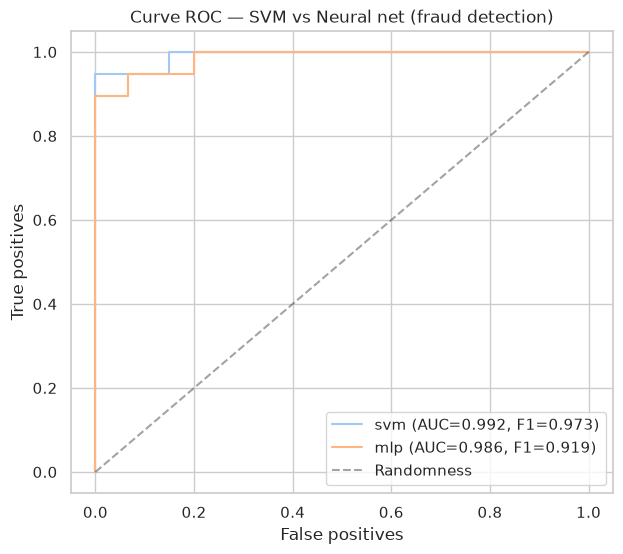

In [166]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

plt.figure(figsize=(7,6))
for name, gs in queries.items():
    prob = gs.predict_proba(X_test)[:, 1]
    pred = gs.predict(X_test)

    f1, auc = f1_score(y_test, pred), roc_auc_score(y_test, prob)
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f}, F1={f1:.3f})')
    print(f'{name:20s} F1 = {f1:.3f} | AUC-ROC = {auc:.3f}')
    
plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Randomness')
plt.xlabel('False positives'); plt.ylabel('True positives')
plt.title('Curve ROC — SVM vs Neural net (fraud detection)')
plt.legend() 
plt.show()   

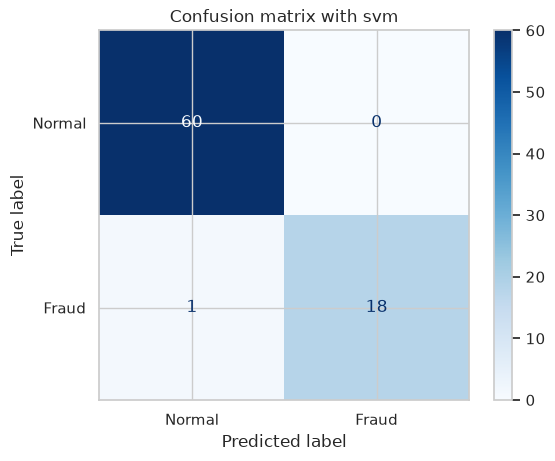

False negatives (not detected frauds): 1


In [170]:
best_name = max(queries, key=lambda n: f1_score(y_test, queries[n].predict(X_test)))
best = queries[best_name]

cm = confusion_matrix(y_test, best.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud']).plot(cmap='Blues')

plt.title(f'Confusion matrix with {best_name}')
plt.show()
print(f'False negatives (not detected frauds): {cm[1,0]}')

## Technical comparation

In [171]:
rows = []

for name, gs in queries.items():
    i = gs.best_index_

    fit_t = gs.cv_results_['mean_fit_time'][i]
    f1_cv = gs.best_score_ 
    f1_test = f1_score(y_test, gs.predict(X_test))

    rows.append({
        'model': name,
        'f1 (validation cv)': round(f1_cv, 3),
        'f1 (test)': round(f1_test, 3),
        'gap (generalization)': round(abs(f1_cv - f1_test), 3),
        'training time (s)': round(fit_t, 2)
    })

comparation = pd.DataFrame(rows)
comparation 

,model,f1 (validation cv),f1 (test),gap (generalization),training time (s)
0,svm,0.937,0.973,0.036,0.06
1,mlp,0.937,0.919,0.018,0.46
